In [2]:
using JLD2
using Plots


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


In [3]:
data_11_13 = jldopen("../25_11_13_output/collated_results.jld2")["results"];
data_11_17 = jldopen("../25_11_17_output/collated_results.jld2")["results"];

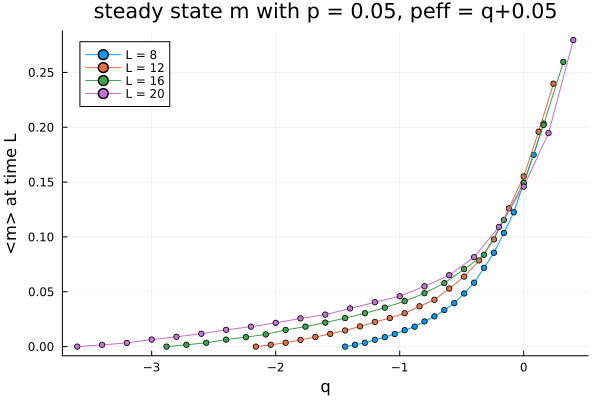

In [34]:
algo = "adv_MWPM"
p = 0.05
Δ = 0.05

plt = plot()
for L in 8:4:20
    qs = 0.0:0.01:0.2
    T = L
    ys = [data_11_13[(algo, L, L, p, q, round(q+Δ,digits=2))][1][T] for q in qs]
    plot!((qs .- 0.18)*L^(1/1), ys, label="L = $L", xlabel="q", ylabel="<m> at time L", m=3, title="steady state m with p = $p, peff = q+$Δ")
end

plt

In [ ]:
[key for key in keys(data_11_17) if key[1] == "adv_MWPM" && key[5] == key[6] && key[5] == 0.0]

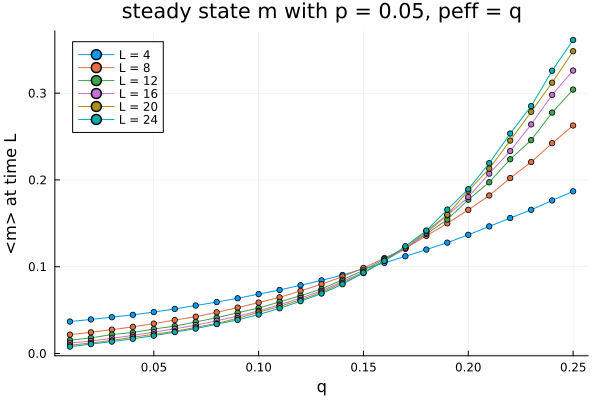

In [76]:
algo = "adv_MWPM"
p = 0.05
Δ = 0.00

plt = plot()
for L in 4:4:24
    qs = 0.01:0.01:0.25
    T = L
    ys = [data_11_17[(algo, L, L, p, q, round(q+Δ,digits=2))][1][T] for q in qs]
    plot!(qs, ys, label="L = $L", xlabel="q", ylabel="<m> at time L", m=3, title="steady state m with p = $p, peff = q")
end
# savefig(plt, "25_11_17_steady_state_m_p_$(p)_peff_eq_q.pdf")
plt

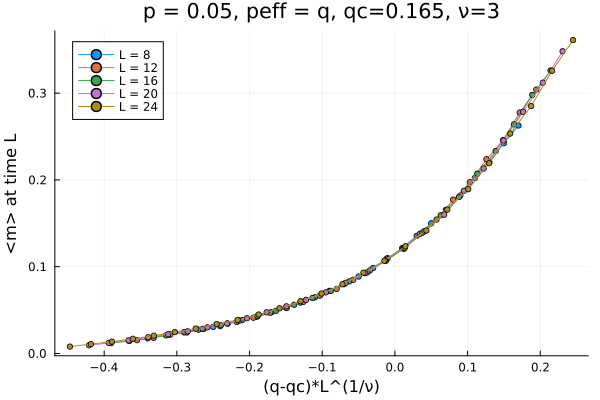

In [80]:
algo = "adv_MWPM"
p = 0.05
Δ = 0.00

qc = 0.165
ν = 3

plt = plot()
for L in 8:4:24
    qs = 0.01:0.01:0.25
    T = L
    ys = [data_11_17[(algo, L, L, p, q, round(q+Δ,digits=2))][1][T] for q in qs]
    plot!((qs .- qc)*L^(1/ν), ys, label="L = $L", xlabel="(q-qc)*L^(1/ν)", ylabel="<m> at time L", m=3, title="p = $p, peff = q, qc=$qc, ν=$ν")
end
# savefig(plt, "25_11_17_steady_state_m_p_$(p)_peff_eq_q.pdf")
plt

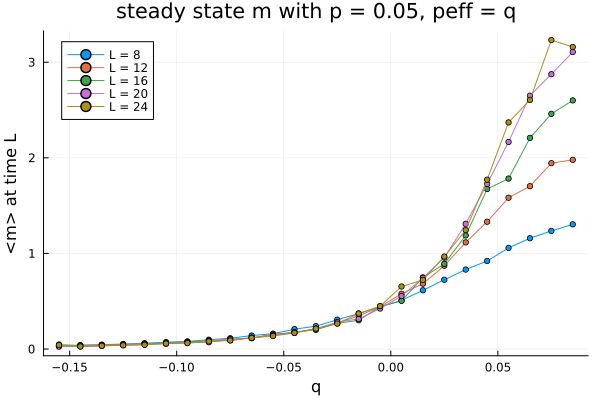

In [46]:
algo = "adv_MWPM"
p = 0.05
Δ = 0.00

plt = plot()
for L in 8:4:24
    qs = 0.01:0.01:0.25
    T = L
    ys = [data_11_17[(algo, L, L, p, q, round(q+Δ,digits=2))][2][T] for q in qs] - [data_11_17[(algo, L, L, p, q, round(q+Δ,digits=2))][1][T] for q in qs].^2
    plot!(qs .- 0.165, L^2*ys, label="L = $L", xlabel="q", ylabel="<m> at time L", m=3, title="steady state m with p = $p, peff = q")
end
# savefig(plt, "25_11_17_steady_state_m_p_$(p)_peff_eq_q.pdf")
plt

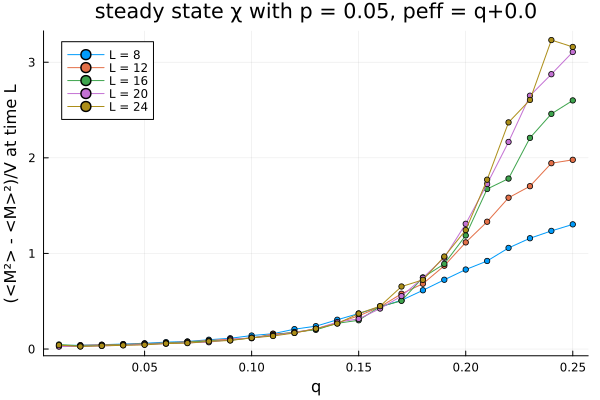

In [45]:
algo = "adv_MWPM"
p = 0.05
Δ = 0.00

plt = plot()
for L in 8:4:24
    qs = 0.01:0.01:0.25
    T = L
    ys = [data_11_17[(algo, L, L, p, q, round(q+Δ,digits=2))][2][T] for q in qs] - [data_11_17[(algo, L, L, p, q, round(q+Δ,digits=2))][1][T] for q in qs] .^ 2
    plot!(qs, L^2*ys, label="L = $L", xlabel="q", ylabel="(<M²> - <M>²)/V at time L", m=3, title="steady state χ with p = $p, peff = q+$Δ")
end

plt

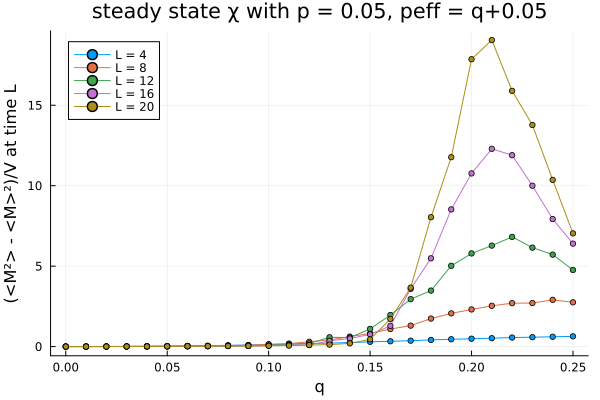

In [44]:
algo = "adv_MWPM"
p = 0.05
Δ = 0.05

plt = plot()
for L in 4:4:20
    qs = 0.0:0.01:0.3-Δ
    T = L
    ys = [data_11_13[(algo, L, L, p, q, round(q+Δ,digits=2))][2][T] for q in qs] - [data_11_13[(algo, L, L, p, q, round(q+Δ,digits=2))][1][T] for q in qs] .^ 2
    plot!(qs, L^2*ys, label="L = $L", xlabel="q", ylabel="(<M²> - <M>²)/V at time L", m=3, title="steady state χ with p = $p, peff = q+$Δ")
end

plt

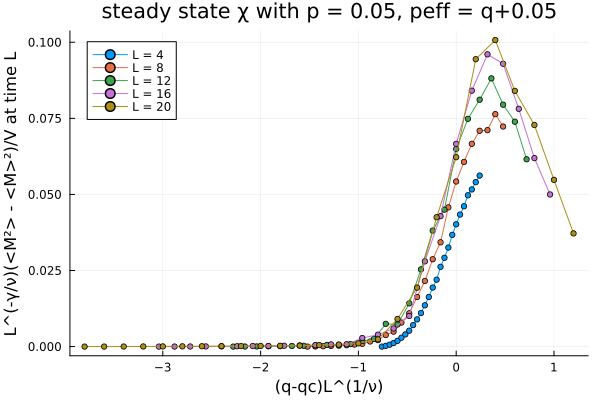

In [69]:
algo = "adv_MWPM"
p = 0.05
Δ = 0.05


qc = 0.19
ν = 1.0
γ = 7/4

plt = plot()
for L in 4:4:20
    qs = 0.0:0.01:0.3-Δ
    T = L
    ys = [data_11_13[(algo, L, L, p, q, round(q+Δ,digits=2))][2][T] for q in qs] - [data_11_13[(algo, L, L, p, q, round(q+Δ,digits=2))][1][T] for q in qs] .^ 2
    
    ys = L^(2-γ/ν) * ys

    qs = (qs .- qc)*L^(1/ν)
    plot!(qs, ys, label="L = $L", xlabel="(q-qc)L^(1/ν)", ylabel="L^(-γ/ν)(<M²> - <M>²)/V at time L", m=3, title="steady state χ with p = $p, peff = q+$Δ")
end

plt

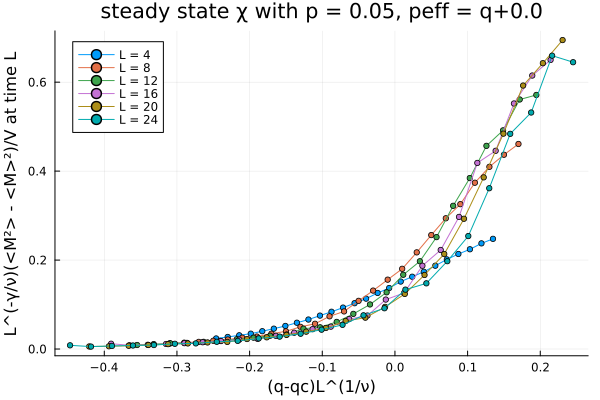

In [72]:
algo = "adv_MWPM"
p = 0.05
Δ = 0.00


qc = 0.165
ν = 3
γ = 1.5

plt = plot()
for L in 4:4:24
    qs = 0.01:0.01:0.25
    T = L
    ys = [data_11_17[(algo, L, L, p, q, round(q+Δ,digits=2))][2][T] for q in qs] - [data_11_17[(algo, L, L, p, q, round(q+Δ,digits=2))][1][T] for q in qs] .^ 2
    
    ys = L^(2-γ/ν) * ys

    qs = (qs .- qc)*L^(1/ν)
    plot!(qs, ys, label="L = $L", xlabel="(q-qc)L^(1/ν)", ylabel="L^(-γ/ν)(<M²> - <M>²)/V at time L", m=3, title="steady state χ with p = $p, peff = q+$Δ")
end

plt